## Caso de Estudio

*Una institución médica desea desarrollar un sistema inteligente capaz de apoyar al especialista durante el diagnóstico de tumores mamarios.*

*El área de informática ha solicitado al equipo de Ciencia de Datos evaluar distintos algoritmos de clasificación para determinar cuál ofrece el mejor desempeño antes de integrarlo al sistema.*

In [1]:
#Carga de librerias
import warnings
import time
import pandas as pd
import matplotlib.pyplot as plt

#Librerias de ML
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#Librerias Algoritmos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
#Librería para evaluación
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
warnings.filterwarnings("ignore")

In [14]:
#Cargamos el dataset
cancer = load_breast_cancer(as_frame=True)
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [15]:
df = cancer.frame

In [16]:
#Exploración
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [18]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [19]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

## Preprocesamiento 

In [20]:
#Cambiar el nombre a la variable objetivo
df.rename(
    columns={"target":"diagnostico"},
    inplace=True
)

In [21]:
df.head(1)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0


In [22]:
#Convertimos los valores
df["diagnostico"] = df["diagnostico"].map({
    0:"Malignant",
    1:"Benign"
})

In [23]:
#Verificamos
df.head(1)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,Malignant


In [24]:
# Variables predictoras
X = df.drop(columns=["diagnostico"])
# Variable objetivo
y = df["diagnostico"]

In [26]:
# Separación de datos para Entrenar y Probar
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
#Escalado de los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Entrenamiento de los modelos


### Modelo 1: KNN

In [28]:
#Entrenamiento
inicio = time.time()
knn = KNeighborsClassifier(
    n_neighbors=5
)
knn.fit(
    X_train_scaled,
    y_train
)
fin = time.time()
tiempo_knn = fin-inicio

In [29]:
#Prediccion
pred_knn = knn.predict(
    X_test_scaled
)

In [30]:
#Exactitud
acc_knn = accuracy_score(
    y_test,
    pred_knn
)

print(acc_knn)

0.956140350877193


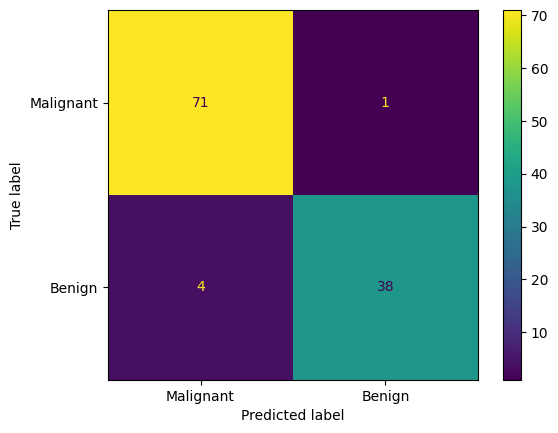

In [31]:
# Matriz de confusión
cm = confusion_matrix(
    y_test,
    pred_knn
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant","Benign"]
).plot()

plt.show()

### Modelo 2: SVM 

In [34]:
#Entrenamiento
inicio = time.time()
svm = SVC()
svm.fit(
    X_train_scaled,
    y_train
)
fin = time.time()
tiempo_svm = fin-inicio

In [35]:
#Prediccion
pred_svm = svm.predict(
    X_test_scaled
)

In [36]:
# Exactitud
acc_svm = accuracy_score(
    y_test,
    pred_svm
)

print(acc_svm)

0.9736842105263158


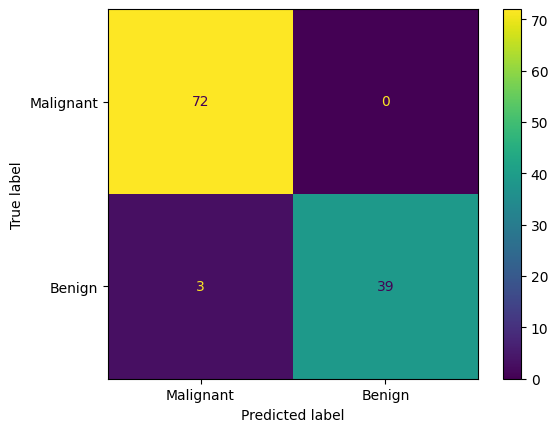

In [37]:
# Matriz de confusion
cm = confusion_matrix( y_test,pred_svm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant","Benign"]
).plot()

plt.show()

### Modelo 3 : Random Forest

In [39]:
inicio = time.time()
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

fin = time.time()

tiempo_rf = fin-inicio

In [41]:
# Entrenamiento
pred_rf = rf.predict(
    X_test
)

In [42]:
# Exactitud
acc_rf = accuracy_score(
    y_test,
    pred_rf
)

print(acc_rf)

0.9736842105263158


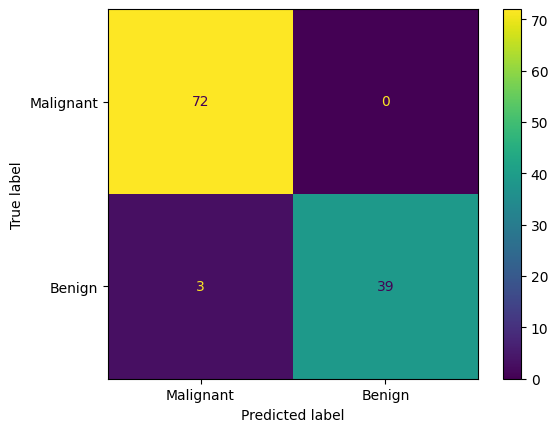

In [43]:
# Matriz de confusión
cm = confusion_matrix(
    y_test,
    pred_rf
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant","Benign"]
).plot()

plt.show()

## Comparación

In [45]:
resultados = pd.DataFrame({
    "Modelo":[
        "KNN",
        "SVM",
        "Random Forest"
    ],
    "Accuracy":[
        acc_knn,
        acc_svm,
        acc_rf
    ],
    "Tiempo Entrenamiento (s)":[
        tiempo_knn,
        tiempo_svm,
        tiempo_rf
    ]

})

In [46]:
print(resultados)

          Modelo  Accuracy  Tiempo Entrenamiento (s)
0            KNN  0.956140                  0.002180
1            SVM  0.973684                  0.005830
2  Random Forest  0.973684                  0.088615


In [47]:
#Importancia de variables
importancias = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importancias.sort_values(
    ascending=False
).head(10)

worst area              0.151412
worst concave points    0.126497
worst radius            0.093475
worst perimeter         0.083642
mean concave points     0.081082
mean perimeter          0.077126
mean radius             0.061990
mean concavity          0.050818
mean area               0.045916
worst concavity         0.030022
dtype: float64

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score

resultadosModelos = pd.DataFrame({
    "Modelo": ["KNN", "SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_svm),
        accuracy_score(y_test, pred_rf)
    ],
    "Precision": [
        precision_score(y_test, pred_knn, pos_label="Malignant"),
        precision_score(y_test, pred_svm, pos_label="Malignant"),
        precision_score(y_test, pred_rf, pos_label="Malignant")
    ],
    "Recall": [
        recall_score(y_test, pred_knn, pos_label="Malignant"),
        precision_score(y_test, pred_svm, pos_label="Malignant"),
        recall_score(y_test, pred_rf, pos_label="Malignant")
    ],
    "F1 Score": [
        f1_score(y_test, pred_knn, pos_label="Malignant"),
        f1_score(y_test, pred_svm, pos_label="Malignant"),
        f1_score(y_test, pred_rf, pos_label="Malignant")
    ]
})

In [49]:
print(resultadosModelos)

          Modelo  Accuracy  Precision    Recall  F1 Score
0            KNN  0.956140   0.974359  0.904762  0.938272
1            SVM  0.973684   1.000000  1.000000  0.962963
2  Random Forest  0.973684   1.000000  0.928571  0.962963
